# Soil Moisture

Author: **Jakob Balkovec**
Date: **Wed Jan 21st**

For more info `@see domain_analysis/README.md`

In [49]:
from pathlib import Path
import math

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import r2_score, mean_absolute_error

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet

from xgboost import XGBRegressor

import json

In [5]:
np.random.seed(42)
sns.set_style("whitegrid")

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "figure.figsize": (10, 5.5),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

In [ ]:
# Paths
SPLIT_ROOT_DIR  = r"/Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits"
DERIVED_NEW_DIR = SPLIT_ROOT_DIR + r"/derived_new/"

TRAIN_NEW = DERIVED_NEW_DIR + r"train_derived_new.csv"
TEST_NEW  =  DERIVED_NEW_DIR + r"test_derived_new.csv"
VAL_NEW   = DERIVED_NEW_DIR + r"val_derived_new.csv"
METADATA  = DERIVED_NEW_DIR + r"split_meta_derived_new.json"

FIGURES   = Path(r"/Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/domain_analysis/figures")
TABLES    = Path(r"/Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/domain_analysis/tables")

FIGURES.mkdir(parents=True, exist_ok=True)
TABLES.mkdir(parents=True, exist_ok=True)

TARGET_COL = "soil_moisture_5cm"

KEEP_META_COLS = ["station_id", "date", "longitude", "latitude"]

FEATURE_COLS = [
  "precip_mm",

  "G_rain_sum_30d",

  "C_lag_E_SAR_diff_kobs12",
  "C_lag_E_SAR_diff_kobs30",
  "C_lag_E_SAR_ratio_kobs30",
  "C_lag_F_NDVI_kobs30",
  "C_lag_LST_modis_kobs12",
  "C_lag_LST_modis_kobs30",
  "DOY",
  "D_sa_E_SAR_ratio",
  "D_sa_F_NDMI",
  "D_z_E_SAR_ratio",
  "D_z_F_NDMI",
  "E_SAR_diff",
  "E_SAR_ratio",
  "F_MSI",
  "F_NDMI",
  "V_ema_LST_modis_kobs30",
  "V_rollmax_E_SAR_diff_kobs14",
  "V_rollmax_E_SAR_diff_kobs30",
  "V_rollmax_F_NDVI_kobs30",
  "V_rollmax_LST_modis_kobs7",
  "V_rollmax_s2_b11_kobs30",
  "V_rollmin_E_SAR_diff_kobs30",
  "V_rollmin_E_SAR_ratio_kobs30",
  "V_rollmin_F_NDMI_kobs30",
  "V_rollmin_s2_b11_kobs30",
  "V_rollmin_s2_b12_kobs30",
  "s1_vh",
  "s2_b8",
  "A_d_LST_modis_kobs7",
  "A_grad_LST_modis_kobs14",
  "C_lag_E_SAR_diff_kobs6",
  "V_rollmax_E_SAR_diff_kobs7",
  "V_rollmax_E_SAR_ratio_kobs14",
  "V_rollmax_F_NDVI_kobs14",
  "s2_b12",
  "D_sa_LST_modis"
]

RAIN_FEATURES = [
  "DOY",

  "precip_mm",
  "G_rain_sum_3d",
  "G_rain_sum_7d",
  "G_rain_sum_30d",
  "G_API",
  "rain_event_impulse_0_7",
  "rain_mm_impulse_0_7",
  "days_since_rain_event",
]

In [14]:
def load_split(path):
    if path.is_dir():
        files = list(path.glob("*.parquet")) + list(path.glob("*.csv"))
        if not files:
            raise FileNotFoundError(f"No parquet/csv files found in {path}")
        dfs = []
        for f in sorted(files):
            if f.suffix == ".parquet":
                dfs.append(pd.read_parquet(f))
            else:
                dfs.append(pd.read_csv(f))
        return pd.concat(dfs, ignore_index=True)

    if path.suffix == ".parquet":
        return pd.read_parquet(path)
    if path.suffix == ".csv":
        return pd.read_csv(path)

    for ext in [".parquet", ".csv"]:
        p = path.with_suffix(ext)
        if p.exists():
            return pd.read_parquet(p) if ext == ".parquet" else pd.read_csv(p)

    raise FileNotFoundError(f"Could not load split at {path}")

In [15]:
def save_fig(name: str):
    stem = name.replace(" ", "_").replace("/", "_")
    plt.tight_layout()
    plt.savefig(FIGURES / f"{stem}.png", bbox_inches="tight")
    plt.savefig(FIGURES / f"{stem}.pdf", bbox_inches="tight")

In [16]:
train_df = load_split(Path(TRAIN_NEW))
val_df   = load_split(Path(VAL_NEW))
test_df  = load_split(Path(TEST_NEW))

meta = json.loads(Path(METADATA).read_text())

In [17]:
RAIN_COL = "precip_mm"
RAIN_THR = 4.0     # from my analysis
K = 7              # 0..7 day short horizon
WEIGHTS = np.array([1.0, 0.6, 0.2, 0.1, 0.05, 0.02, 0.01, 0.0], dtype=float)  # len = K+1
NEW_FEATURES = [
    "rain_event_impulse_0_7",
    "rain_mm_impulse_0_7",
    "days_since_rain_event",
]

def add_rain_impulse_features(d: pd.DataFrame) -> pd.DataFrame:
    d = d.copy()
    d["date"] = pd.to_datetime(d["date"], errors="coerce")
    d = d.sort_values(["station_id", "date"]).reset_index(drop=True)

    d["_rain_event"] = (d[RAIN_COL] >= RAIN_THR).astype(int)

    for k in range(0, K + 1):
        d[f"_ev_lag{k}"] = d.groupby("station_id")["_rain_event"].shift(k)
        d[f"_mm_lag{k}"] = d.groupby("station_id")[RAIN_COL].shift(k)

    ev_cols = [f"_ev_lag{k}" for k in range(0, K + 1)]
    mm_cols = [f"_mm_lag{k}" for k in range(0, K + 1)]

    ev_mat = d[ev_cols].fillna(0).to_numpy(dtype=float)
    mm_mat = d[mm_cols].fillna(0).to_numpy(dtype=float)

    d["rain_event_impulse_0_7"] = (ev_mat * WEIGHTS).sum(axis=1)
    d["rain_mm_impulse_0_7"]    = (mm_mat * WEIGHTS).sum(axis=1)

    def _days_since_event(group: pd.DataFrame) -> pd.Series:
        ev = group["_rain_event"].to_numpy()
        out = np.full(len(ev), np.nan, dtype=float)
        last_idx = None
        for i in range(len(ev)):
            if ev[i] == 1:
                last_idx = i
                out[i] = 0.0
            else:
                if last_idx is not None:
                    out[i] = float(i - last_idx)
        return pd.Series(out, index=group.index)

    d["days_since_rain_event"] = (
        d.groupby("station_id", group_keys=False)
         .apply(_days_since_event)
         .clip(upper=30)
    )

    drop_cols = ["_rain_event"] + ev_cols + mm_cols
    d.drop(columns=drop_cols, inplace=True, errors="ignore")

    return d

train_df = add_rain_impulse_features(train_df)
val_df   = add_rain_impulse_features(val_df)
test_df  = add_rain_impulse_features(test_df)

for f in NEW_FEATURES:
    if f not in FEATURE_COLS:
        FEATURE_COLS.append(f)

print("Added new features:", NEW_FEATURES)
print("Total features now:", len(FEATURE_COLS))

for name, d in [("train", train_df), ("val", val_df), ("test", test_df)]:
    miss = [c for c in NEW_FEATURES if c not in d.columns]
    if miss:
        raise ValueError(f"{name} missing new features: {miss}")
    print(f"{name}:",
          d[NEW_FEATURES].isna().mean().round(3).to_dict())

Added new features: ['rain_event_impulse_0_7', 'rain_mm_impulse_0_7', 'days_since_rain_event']
Total features now: 41
train: {'rain_event_impulse_0_7': 0.0, 'rain_mm_impulse_0_7': 0.0, 'days_since_rain_event': 0.002}
val: {'rain_event_impulse_0_7': 0.0, 'rain_mm_impulse_0_7': 0.0, 'days_since_rain_event': 0.003}
test: {'rain_event_impulse_0_7': 0.0, 'rain_mm_impulse_0_7': 0.0, 'days_since_rain_event': 0.008}


In [18]:
# Dropping TouchNet because it has no rows in the validation split

DROP_STATION = "Touchet_WA_824"

def drop_station(df, station_id=DROP_STATION):
    before = len(df)
    out = df[df["station_id"] != station_id].copy()
    after = len(out)
    print(f"Dropped {station_id}: {before} -> {after} rows (-{before-after})")
    return out

train_df = drop_station(train_df)
val_df   = drop_station(val_df)
test_df  = drop_station(test_df)

Dropped Touchet_WA_824: 16972 -> 13661 rows (-3311)
Dropped Touchet_WA_824: 2919 -> 2919 rows (-0)
Dropped Touchet_WA_824: 2829 -> 2659 rows (-170)


In [19]:
def schema_snapshot(df: pd.DataFrame, name: str, n=5):
    display(df.head(n))
    snap = pd.DataFrame({
        "col": df.columns,
        "dtype": [str(t) for t in df.dtypes],
        "n_missing": df.isna().sum().values,
        "pct_missing": (df.isna().mean().values * 100.0),
    }).sort_values(["pct_missing", "col"], ascending=[False, True])
    display(snap)

In [20]:
schema_snapshot(train_df, "train_df")

,station_id,date,longitude,latitude,precip_mm,s1_vv,s1_vh,s2_b4,s2_b8,s2_b11,...,D_fft_dom_F_NDMI_kobs30,D_fft_ent_F_NDMI_kobs30,D_fft_dom_E_SAR_ratio_kobs30,D_fft_ent_E_SAR_ratio_kobs30,D_fft_dom_LST_modis_kobs30,D_fft_ent_LST_modis_kobs30,G_DSLR_isnan,rain_event_impulse_0_7,rain_mm_impulse_0_7,days_since_rain_event
0,Darrington,2011-10-06,-121.45,48.54,1.5,0.083914,0.024101,0.120266,0.315849,0.215994,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0.0,1.500,NaN
1,Darrington,2011-10-07,-121.45,48.54,3.0,0.083914,0.024101,0.120266,0.315849,0.215994,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0.0,3.900,NaN
2,Darrington,2011-10-08,-121.45,48.54,0.2,0.083914,0.024101,0.120266,0.315849,0.215994,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0.0,2.300,NaN
3,Darrington,2011-10-09,-121.45,48.54,1.6,0.083914,0.024101,0.120266,0.315849,0.215994,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0.0,2.470,NaN
4,Darrington,2011-10-10,-121.45,48.54,16.1,0.083914,0.024101,0.120266,0.315849,0.215994,...,NaN,NaN,NaN,NaN,NaN,NaN,0,1.0,17.475,0.0


,col,dtype,n_missing,pct_missing
337,H_corr_E_SAR_ratio__F_NDMI_kobs7,float64,6725,49.227729
336,I_ts_spike_s1_vv,float64,5888,43.100798
338,H_corr_E_SAR_ratio__F_NDMI_kobs14,float64,5690,41.651416
339,H_corr_LST_modis__F_NDMI_kobs7,float64,4235,31.000659
340,H_corr_LST_modis__F_NDMI_kobs14,float64,2761,20.210819
...,...,...,...,...
7,s2_b4,float64,0,0.000000
8,s2_b8,float64,0,0.000000
13,slope,float64,0,0.000000
16,soil_moisture_5cm,float64,0,0.000000


In [ ]:
y_train = train_df[TARGET_COL].values
y_val   = val_df[TARGET_COL].values
y_test  = test_df[TARGET_COL].values

In [23]:
TARGET = "soil_moisture_5cm"

assert TARGET in train_df.columns
assert TARGET in val_df.columns
assert TARGET in test_df.columns

print("Target stats:")
display(
    pd.concat([
        train_df[TARGET].describe().rename("train"),
        val_df[TARGET].describe().rename("val"),
        test_df[TARGET].describe().rename("test"),
    ], axis=1)
)

Target stats:


,train,val,test
count,13661.000000,2919.000000,2659.000000
mean,0.205418,0.220604,0.217668
std,0.102642,0.100735,0.096083
min,0.000000,0.028000,0.015000
25%,0.120000,0.127000,0.147000
50%,0.216000,0.253000,0.247000
75%,0.297000,0.302000,0.295000
max,0.503000,0.444000,0.378000


In [26]:
def infer_family(col):
    if col.startswith("G_"): return "Rain | Climate"
    if col.startswith("F_"): return "Optical"
    if col.startswith("E_"): return "SAR"
    if col.startswith("D_"): return "Seasonal | Static"
    if col.startswith("V_"): return "Rolling | Extremes"
    if col.startswith("C_"): return "Lagged"
    if col.startswith("A_"): return "Derivatives"
    return "Base | Other"

feature_cols = [c for c in train_df.columns if c not in [
    "station_id", "date", "longitude", "latitude", TARGET
]]

family_df = (
    pd.Series(feature_cols, name="feature")
      .to_frame()
      .assign(family=lambda x: x["feature"].map(infer_family))
)

family_df["family"].value_counts()

family
Rolling | Extremes    168
Derivatives            80
Lagged                 56
Base | Other           20
Seasonal | Static      12
SAR                     7
Rain | Climate          6
Optical                 3
Name: count, dtype: int64

In [27]:
miss = train_df[feature_cols].isna().mean()

family_missing = (
    family_df
    .assign(missing=family_df["feature"].map(miss))
    .groupby("family")["missing"]
    .agg(["mean", "max", "count"])
    .sort_values("mean", ascending=False)
)

display(family_missing)

,mean,max,count
family,,,
Base | Other,0.092731,0.492277,20
Seasonal | Static,0.004392,0.008784,12
Rolling | Extremes,0.004016,0.008491,168
Derivatives,0.003250,0.008784,80
Lagged,0.002342,0.008784,56
SAR,0.001966,0.004392,7
Rain | Climate,0.000012,0.000073,6
Optical,0.000000,0.000000,3


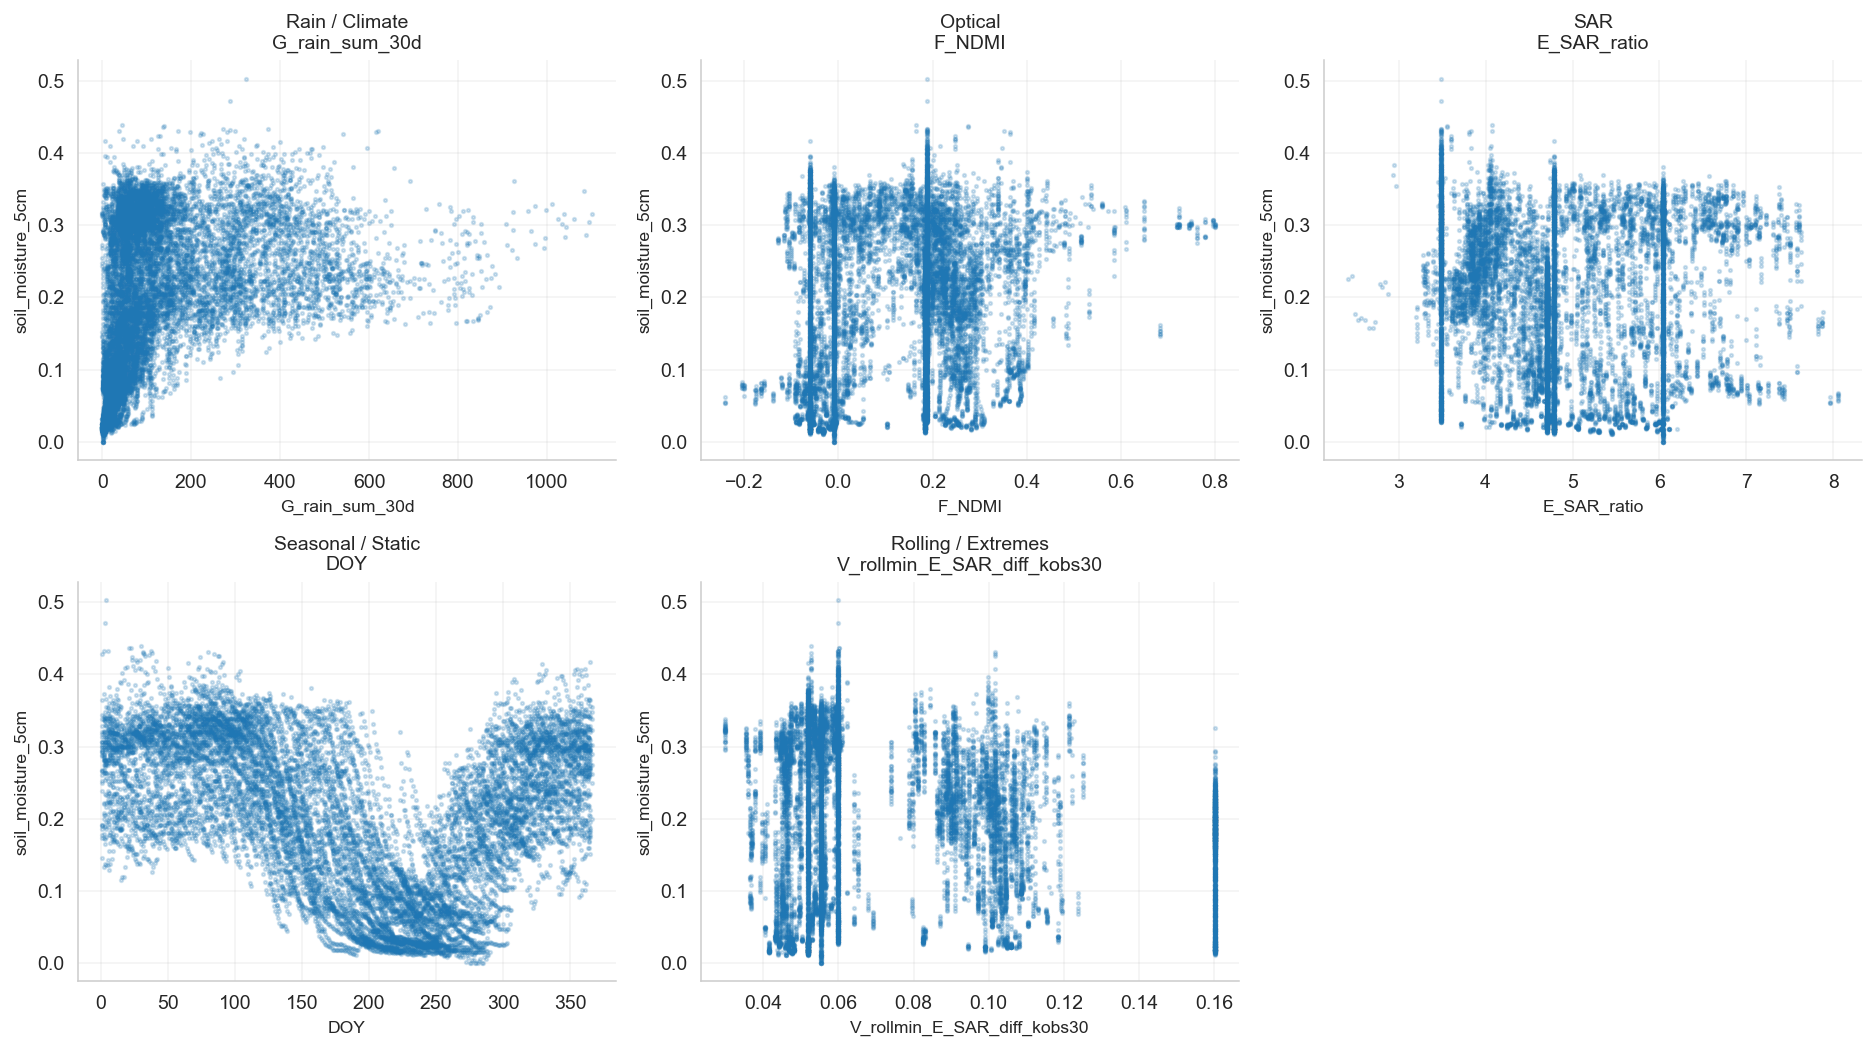

In [31]:
example_features = {
    "Rain / Climate": "G_rain_sum_30d",
    "Optical": "F_NDMI",
    "SAR": "E_SAR_ratio",
    "Seasonal / Static": "DOY",
    "Rolling / Extremes": "V_rollmin_E_SAR_diff_kobs30",
}

pairs = [(fam, col) for fam, col in example_features.items() if col in train_df.columns]

n = len(pairs)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 3.8 * nrows))
axes = axes.flatten()

for ax, (fam, col) in zip(axes, pairs):
    ax.scatter(
        train_df[col],
        train_df[TARGET],
        s=3,
        alpha=0.2
    )
    ax.set_title(f"{fam}\n{col}", fontsize=10)
    ax.set_xlabel(col, fontsize=9)
    ax.set_ylabel(TARGET, fontsize=9)

# turn off unused axes
for ax in axes[len(pairs):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
X = train_df[feature_cols].copy()

inf_counts = np.isinf(X.to_numpy(dtype=float, copy=False)).sum(axis=0)
inf_cols = [c for c, n in zip(X.columns, inf_counts) if n > 0]

THR = 1e10
huge_cols = [c for c in X.columns if pd.to_numeric(X[c], errors="coerce").abs().max(skipna=True) > THR]

print("Columns with inf:", len(inf_cols))
print(inf_cols[:30])

print("\nColumns with abs(max) >", THR, ":", len(huge_cols))
print(huge_cols[:30])

if inf_cols:
    c = inf_cols[0]
    print(f"\nSample rows with inf in {c}:")
    display(train_df.loc[np.isinf(train_df[c].astype(float)), ["station_id","date",c]].head(10))

if huge_cols:
    c = huge_cols[0]
    s = pd.to_numeric(train_df[c], errors="coerce")
    print(f"\nMax abs in {c}:", s.abs().max())

Columns with inf: 4
['H_corr_E_SAR_ratio__F_NDMI_kobs7', 'H_corr_E_SAR_ratio__F_NDMI_kobs14', 'H_corr_LST_modis__F_NDMI_kobs7', 'H_corr_LST_modis__F_NDMI_kobs14']

Columns with abs(max) > 10000000000.0 : 4
['H_corr_E_SAR_ratio__F_NDMI_kobs7', 'H_corr_E_SAR_ratio__F_NDMI_kobs14', 'H_corr_LST_modis__F_NDMI_kobs7', 'H_corr_LST_modis__F_NDMI_kobs14']

Sample rows with inf in H_corr_E_SAR_ratio__F_NDMI_kobs7:


,station_id,date,H_corr_E_SAR_ratio__F_NDMI_kobs7
1416,Darrington,2015-10-13,inf
1419,Darrington,2015-10-16,inf
1424,Darrington,2015-10-21,inf
1425,Darrington,2015-10-22,-inf
1427,Darrington,2015-10-24,inf
1429,Darrington,2015-10-26,-inf
1430,Darrington,2015-10-27,-inf
1432,Darrington,2015-10-29,inf
1433,Darrington,2015-10-30,-inf
1436,Darrington,2015-11-02,-inf



Max abs in H_corr_E_SAR_ratio__F_NDMI_kobs7: inf


In [ ]:
X = train_df[feature_cols].copy()
y = train_df[TARGET].values

X = X.replace([np.inf, -np.inf], np.nan)

CLIP_Q = 0.001  # clip 0.1% tails
lo = X.quantile(CLIP_Q)
hi = X.quantile(1 - CLIP_Q)
X = X.clip(lower=lo, upper=hi, axis=1)

enet = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("sc", StandardScaler()),
    ("m", ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=20000, random_state=42)),
])

enet.fit(X, y)

print("[OK] ElasticNet fit completed.")

[OK] ElasticNet fit completed.


In [36]:
yhat = enet.predict(X)
err = y - yhat

train_df.assign(
    error=err,
    abs_error=np.abs(err)
).groupby("station_id")["abs_error"].mean().sort_values(ascending=False)

station_id
SourdoughGulch_WA_985    0.053973
Darrington               0.048598
Spokane                  0.044434
Quinault                 0.031826
Name: abs_error, dtype: float64

In [37]:
df = train_df.copy()
df["abs_error"] = np.abs(df[TARGET] - yhat)

def doy_bin(doy):
    if doy <= 90 or doy >= 335:
        return "winter"
    elif doy <= 150 or doy >= 275:
        return "shoulder"
    else:
        return "summer"

df["season"] = df["DOY"].apply(doy_bin)

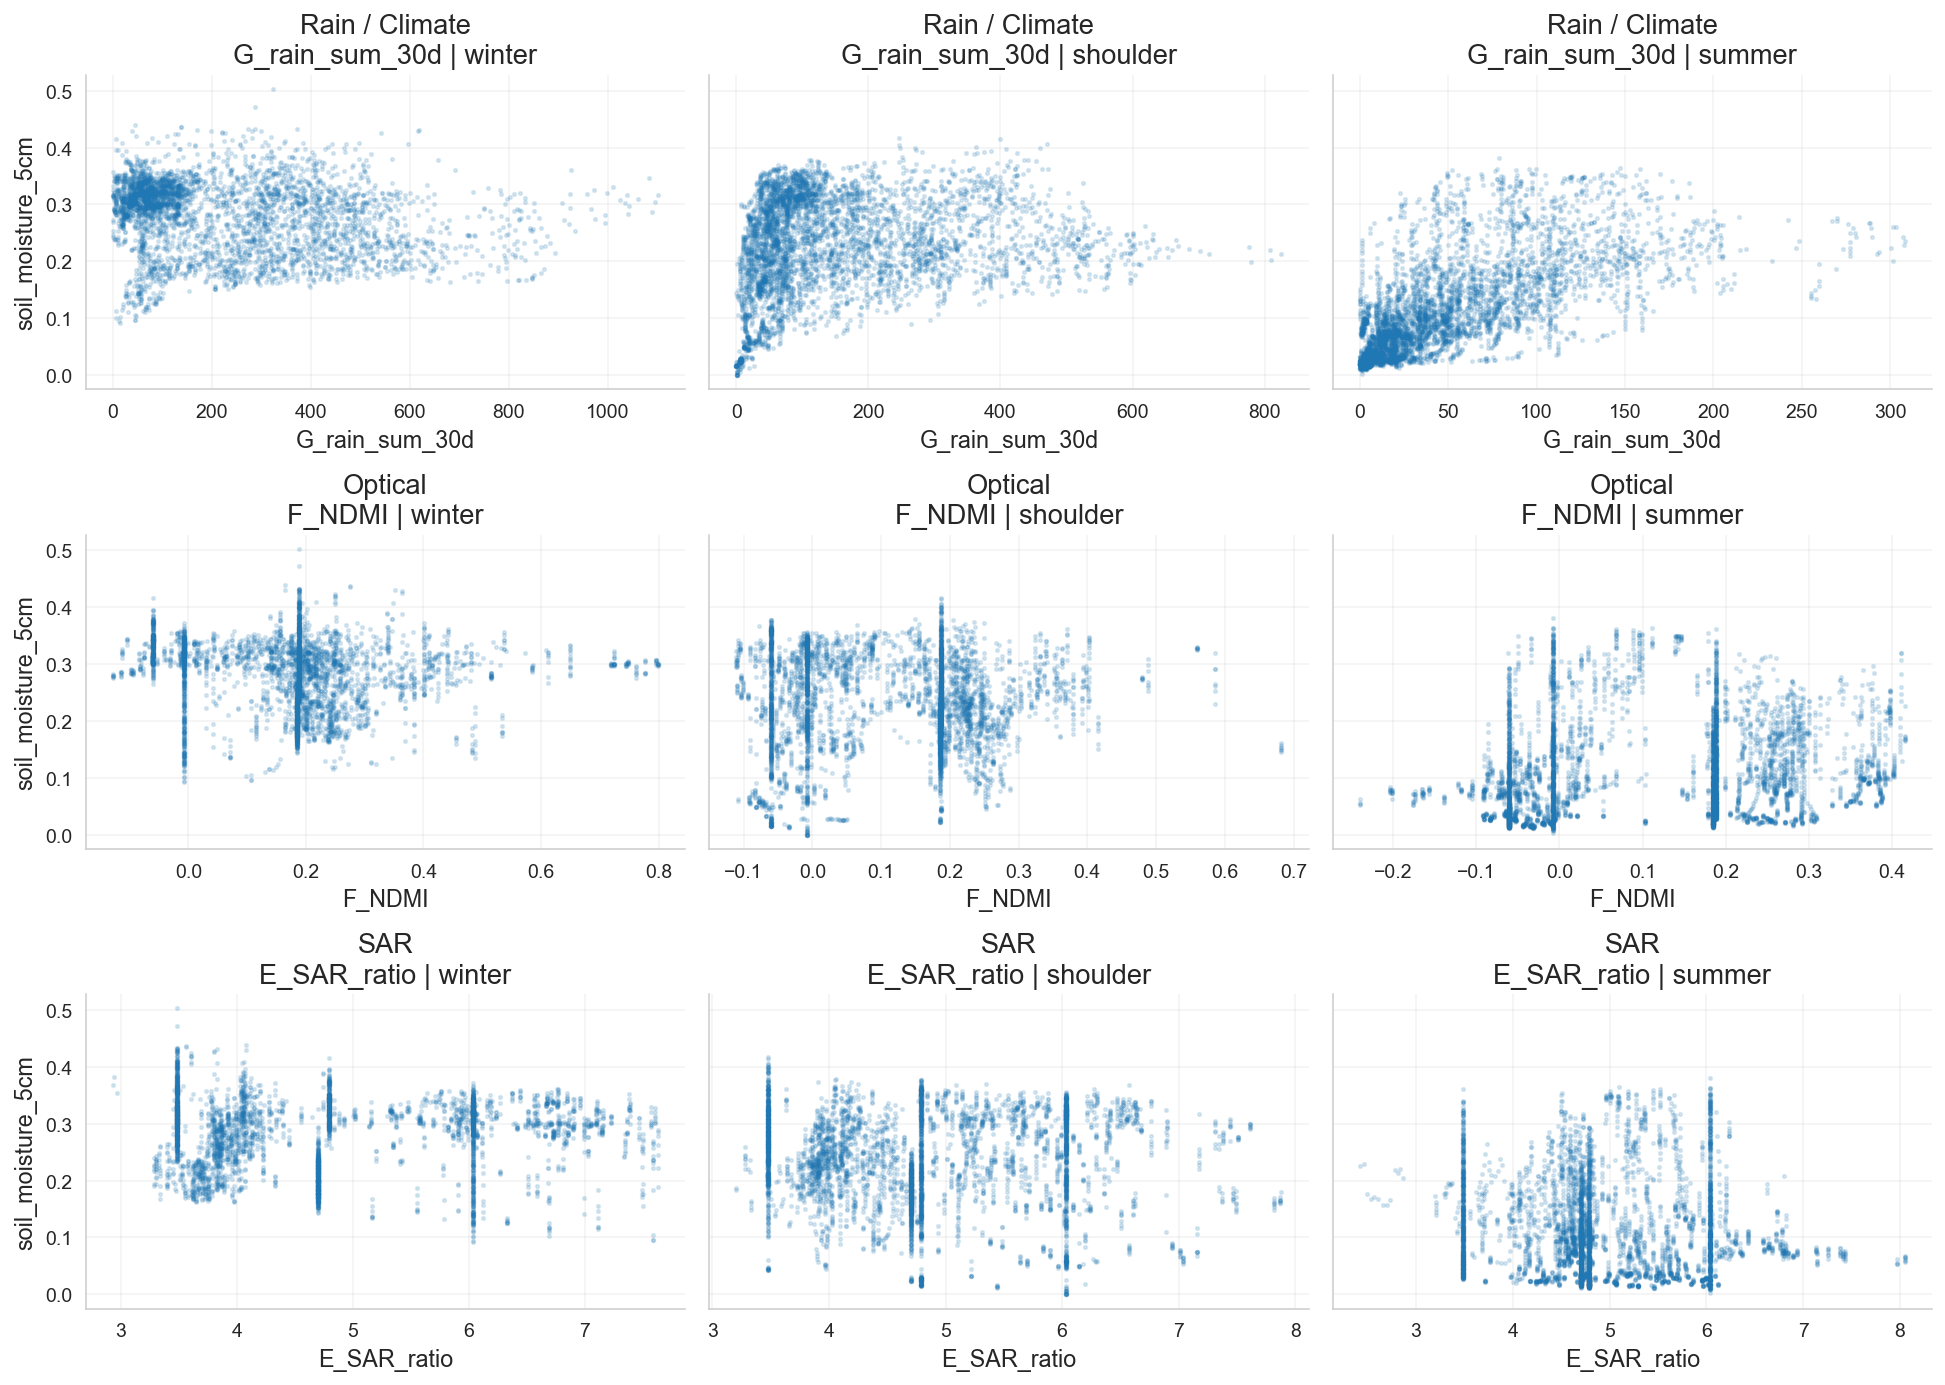

In [38]:
features = {
    "Rain / Climate": "G_rain_sum_30d",
    "Optical": "F_NDMI",
    "SAR": "E_SAR_ratio",
}

fig, axes = plt.subplots(
    nrows=len(features),
    ncols=3,
    figsize=(14, 10),
    sharey=True
)

seasons = ["winter", "shoulder", "summer"]

for i, (fam, col) in enumerate(features.items()):
    for j, season in enumerate(seasons):
        ax = axes[i, j]
        sub = df[df["season"] == season]

        ax.scatter(
            sub[col],
            sub[TARGET],
            s=3,
            alpha=0.15
        )
        ax.set_title(f"{fam}\n{col} | {season}")
        ax.set_xlabel(col)
        if j == 0:
            ax.set_ylabel("soil_moisture_5cm")

plt.tight_layout()
plt.show()

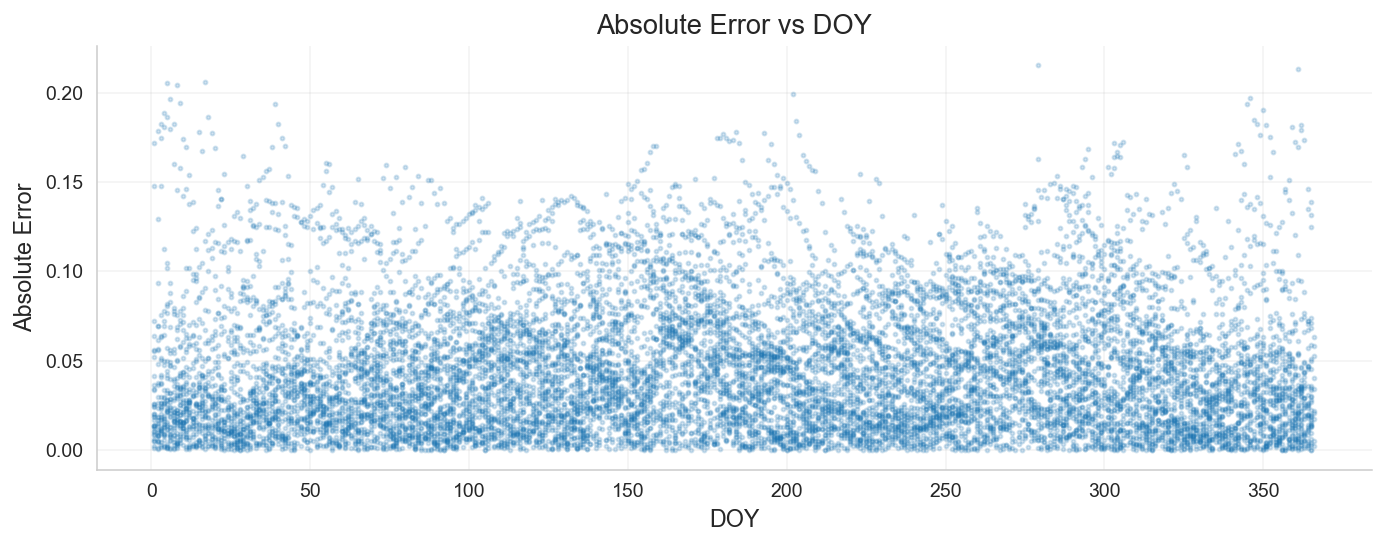

In [39]:
plt.figure(figsize=(10,4))
plt.scatter(
    df["DOY"],
    df["abs_error"],
    s=4,
    alpha=0.2
)
plt.xlabel("DOY")
plt.ylabel("Absolute Error")
plt.title("Absolute Error vs DOY")
plt.tight_layout()
plt.show()

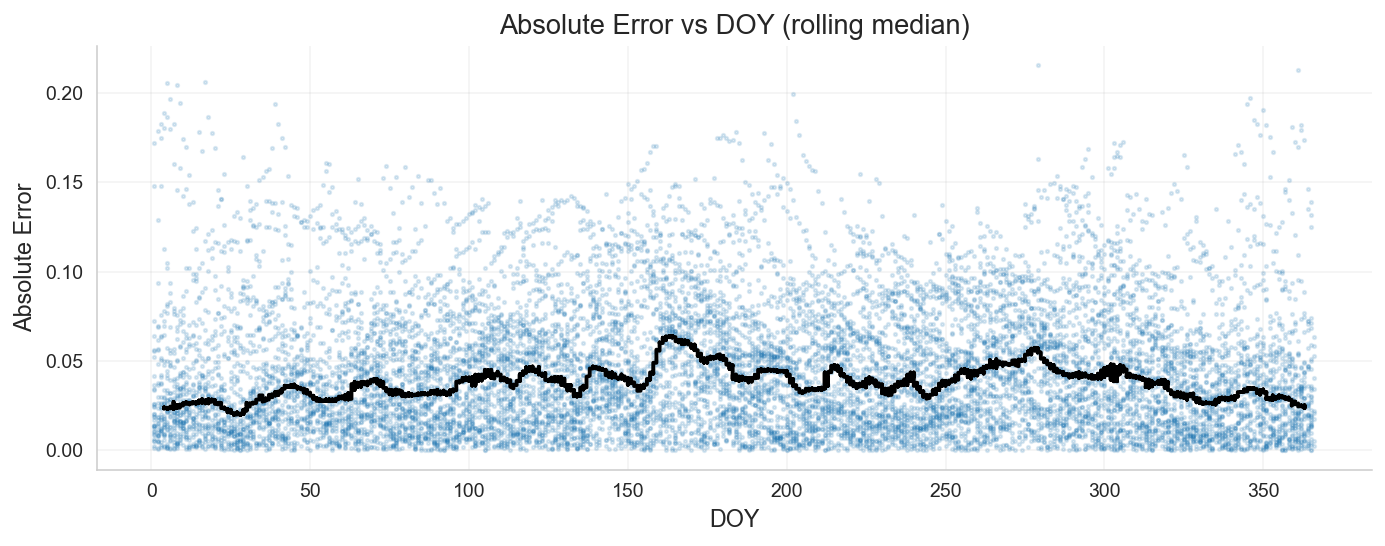

In [40]:
df_sorted = df.sort_values("DOY")
roll = df_sorted["abs_error"].rolling(200, center=True).median()

plt.figure(figsize=(10,4))
plt.scatter(df_sorted["DOY"], df_sorted["abs_error"], s=3, alpha=0.15)
plt.plot(df_sorted["DOY"], roll, color="black", linewidth=2)
plt.xlabel("DOY")
plt.ylabel("Absolute Error")
plt.title("Absolute Error vs DOY (rolling median)")
plt.tight_layout()
plt.show()

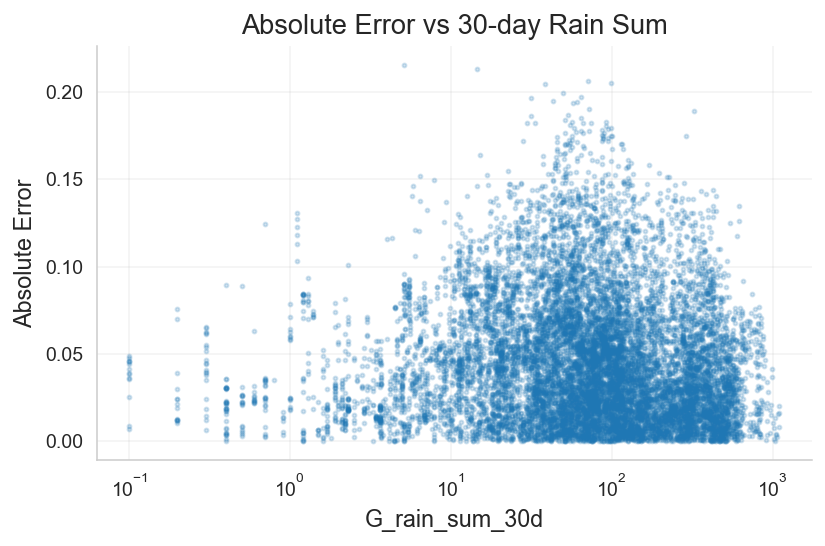

In [ ]:
# NOTE: LOG SCALE

plt.figure(figsize=(6,4))
plt.scatter(
    df["G_rain_sum_30d"],
    df["abs_error"],
    s=4,
    alpha=0.2
)
plt.xlabel("G_rain_sum_30d")
plt.ylabel("Absolute Error")
plt.title("Absolute Error vs 30-day Rain Sum")
plt.xscale("log")
plt.tight_layout()
plt.show()

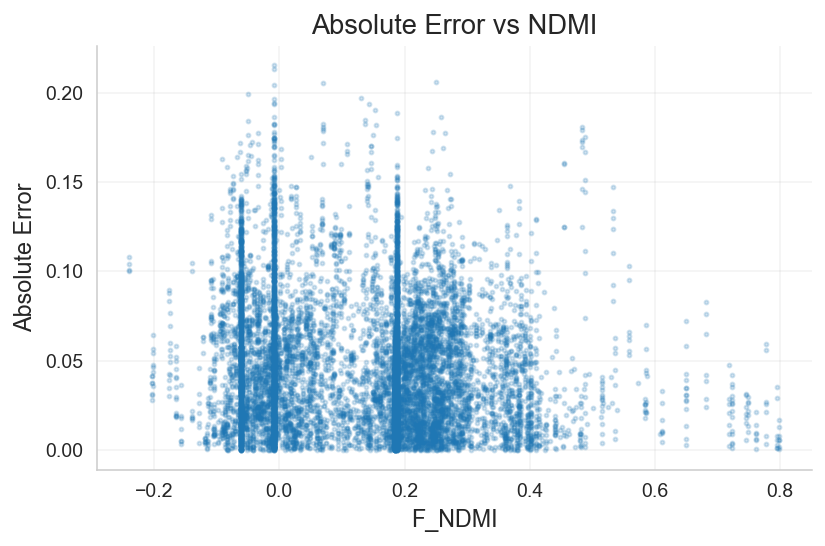

In [43]:
plt.figure(figsize=(6,4))
plt.scatter(
    df["F_NDMI"],
    df["abs_error"],
    s=4,
    alpha=0.2
)
plt.xlabel("F_NDMI")
plt.ylabel("Absolute Error")
plt.title("Absolute Error vs NDMI")
plt.tight_layout()
plt.show()

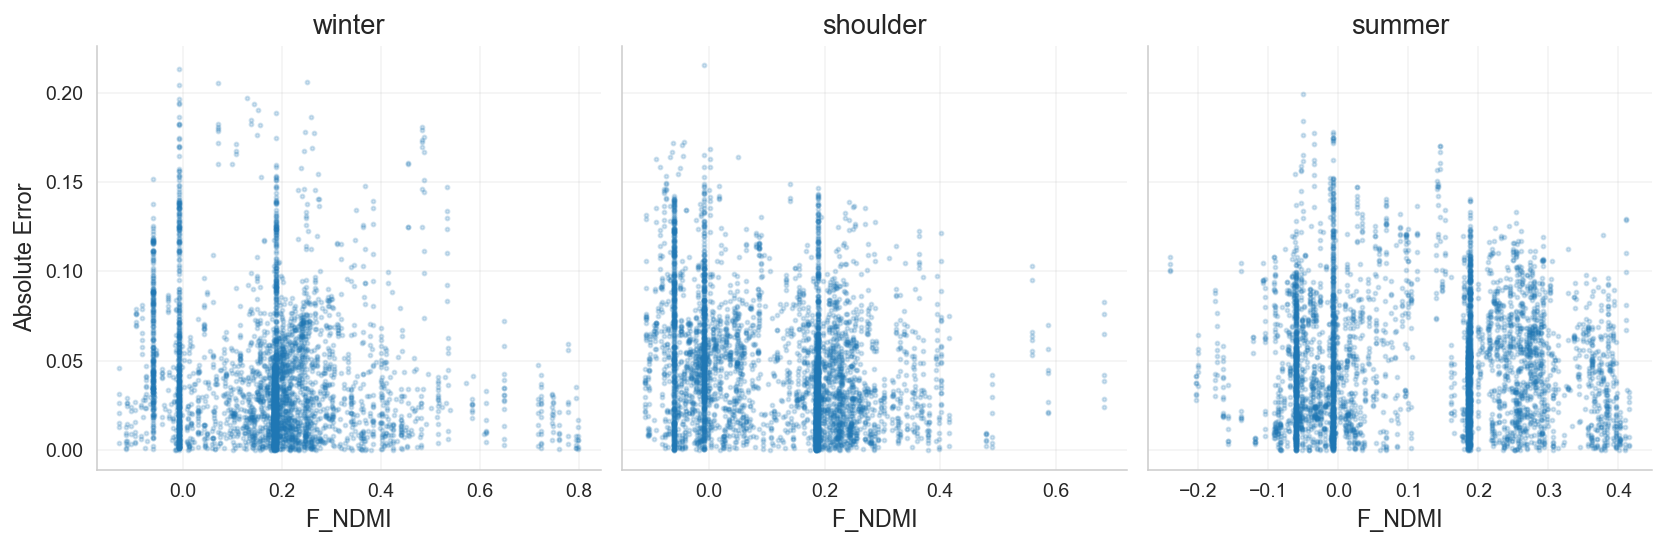

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(12,4), sharey=True)

for ax, season in zip(axes, seasons):
    sub = df[df["season"] == season]
    ax.scatter(sub["F_NDMI"], sub["abs_error"], s=4, alpha=0.2)
    ax.set_title(season)
    ax.set_xlabel("F_NDMI")

axes[0].set_ylabel("Absolute Error")
plt.tight_layout()
plt.show()

In [64]:
def add_season_bins(df):
    def doy_bin(doy):
        if doy <= 90 or doy >= 335:
            return "winter"
        elif doy <= 150 or doy >= 275:
            return "shoulder"
        else:
            return "summer"
    out = df.copy()
    out["season"] = out["DOY"].apply(doy_bin)
    return out

def r2_by_group(df, group_col):
    rows = []
    for g, sub in df.groupby(group_col):
        if len(sub) < 50:
            continue
        rows.append({
            group_col: g,
            "n": len(sub),
            "R2": float(r2_score(sub["y_true"], sub["y_pred"]))
        })
    return pd.DataFrame(rows).sort_values("R2")

In [68]:
X_train = train_df[feature_cols].copy().replace([np.inf, -np.inf], np.nan)

CLIP_Q = 0.001
lo = X_train.quantile(CLIP_Q)
hi = X_train.quantile(1 - CLIP_Q)
X_train = X_train.clip(lower=lo, upper=hi, axis=1)

yhat_train_aligned = enet.predict(X_train)

print("len(train_df):", len(train_df))
print("len(yhat_train_aligned):", len(yhat_train_aligned))

len(train_df): 13661
len(yhat_train_aligned): 13661


In [69]:
df = train_df.copy()
df["y_true"] = df[TARGET].values
df["y_pred"] = yhat_train_aligned

df["season"] = df["DOY"].apply(doy_bin)

rain_col = "G_rain_sum_30d"
df["rain_regime"] = pd.qcut(
    df[rain_col].rank(method="first"), 3,
    labels=["low_rain", "mid_rain", "high_rain"]
)

print("Overall R² (train):", float(r2_score(df["y_true"], df["y_pred"])))
display(r2_by_group(df, "season"))
display(r2_by_group(df, "rain_regime"))

df["season_x_rain"] = df["season"].astype(str) + " | " + df["rain_regime"].astype(str)
display(r2_by_group(df, "season_x_rain"))

Overall R² (train): 0.6947783543437815


,season,n,R2
2,winter,4076,0.242390
0,shoulder,4704,0.503531
1,summer,4881,0.505369


,rain_regime,n,R2
2,high_rain,4554,0.444895
1,mid_rain,4553,0.506975
0,low_rain,4554,0.664524


,season_x_rain,n,R2
7,winter | low_rain,570,-0.351373
8,winter | mid_rain,1266,-0.044378
4,summer | low_rain,2882,0.027885
3,summer | high_rain,426,0.168923
5,summer | mid_rain,1573,0.318789
2,shoulder | mid_rain,1714,0.359562
0,shoulder | high_rain,1888,0.402475
6,winter | high_rain,2240,0.455582
1,shoulder | low_rain,1102,0.505771


In [70]:
df = df.copy()
df["resid"] = df["y_true"] - df["y_pred"]
df["abs_err"] = df["resid"].abs()

thr = df["abs_err"].quantile(0.8)
bad = df[df["abs_err"] >= thr]
good = df[df["abs_err"] < thr]

def infer_family(col):
    if col.startswith("G_") or col.startswith("rain_") or col.startswith("precip"): return "RAIN/CLIMATE"
    if col.startswith("F_"): return "OPTICAL"
    if col.startswith("E_") or "SAR" in col: return "SAR"
    if col.startswith("V_"): return "ROLLING/EXTREMES"
    if col.startswith("C_"): return "LAGGED"
    if col.startswith("A_"): return "DERIVATIVES"
    if col.startswith("D_") or col in ["DOY"]: return "SEASON/STATIC"
    return "OTHER"

feature_cols = [c for c in df.columns if c not in [
    "station_id","date","longitude","latitude",TARGET,
    "y_true","y_pred","resid","abs_err","season","rain_regime","season_x_rain"
] and pd.api.types.is_numeric_dtype(df[c])]

fam_map = {c: infer_family(c) for c in feature_cols}

rows = []
for fam in sorted(set(fam_map.values())):
    cols = [c for c in feature_cols if fam_map[c] == fam]
    if len(cols) == 0:
        continue

    smds = []
    for c in cols:
        g = good[c].astype(float)
        b = bad[c].astype(float)
        mu_g, mu_b = g.mean(skipna=True), b.mean(skipna=True)
        sd = np.nanstd(pd.concat([g,b], axis=0).values)
        if sd == 0 or np.isnan(sd):
            continue
        smds.append(abs(mu_b - mu_g) / sd)

    rows.append({
        "family": fam,
        "n_features": len(cols),
        "avg_SMD_bad_vs_good": float(np.nanmean(smds)) if len(smds) else np.nan,
        "median_SMD_bad_vs_good": float(np.nanmedian(smds)) if len(smds) else np.nan,
    })

fam_shift = pd.DataFrame(rows).sort_values("avg_SMD_bad_vs_good", ascending=False)
fam_shift

/Users/jbalkovec/miniforge3/envs/dr-arm/lib/python3.10/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/Users/jbalkovec/miniforge3/envs/dr-arm/lib/python3.10/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/Users/jbalkovec/miniforge3/envs/dr-arm/lib/python3.10/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/Users/jbalkovec/miniforge3/envs/dr-arm/lib/python3.10/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


,family,n_features,avg_SMD_bad_vs_good,median_SMD_bad_vs_good
2,OPTICAL,3,0.267230,0.299372
1,LAGGED,42,0.263353,0.289227
3,OTHER,14,0.218715,0.253781
5,ROLLING/EXTREMES,126,0.190882,0.211978
4,RAIN/CLIMATE,9,0.136817,0.122034
6,SAR,89,0.133285,0.087543
7,SEASON/STATIC,9,0.094294,0.058641
0,DERIVATIVES,60,0.035420,0.029721


In [71]:
MODEL_CONFIG = {
    "objective":        "reg:squarederror",
    "n_estimators":     500,          # upper bound, early stopping will cap it
    "max_depth":        5, # can try 6 with stronger regularization
    "learning_rate":    0.05,
    "subsample":        0.8,
    "colsample_bytree": 0.8,
    "reg_alpha":        0.0,
    "reg_lambda":       1.0,
    "random_state":     42,
    "n_jobs":           -1,
}

In [72]:
def eval_block(y, yhat):
    rmse = np.sqrt(np.mean((y - yhat) ** 2))
    return {
        "R2": float(r2_score(y, yhat)),
        "MAE": float(mean_absolute_error(y, yhat)),
        "RMSE": float(rmse),
    }


X_COLS = FEATURE_COLS

train_s = add_season_bins(train_df)
test_s  = add_season_bins(test_df)

results = []
models = {}

for season in ["winter", "shoulder", "summer"]:
    tr = train_s[train_s["season"] == season]
    te = test_s[test_s["season"] == season]

    Xtr, ytr = tr[X_COLS], tr[TARGET].values
    Xte, yte = te[X_COLS], te[TARGET].values

    m = XGBRegressor(**MODEL_CONFIG)
    m.fit(Xtr, ytr)

    yhat = m.predict(Xte)
    res = eval_block(yte, yhat)
    res.update({"season": season, "n_train": len(tr), "n_test": len(te)})
    results.append(res)
    models[season] = m

pd.DataFrame(results).sort_values("R2")

,R2,MAE,RMSE,season,n_train,n_test
0,-0.555362,0.045641,0.056934,winter,4076,858
2,0.480256,0.041235,0.055052,summer,4881,885
1,0.550895,0.034579,0.043057,shoulder,4704,916


What is actually “throwing off” the model
1. Winter (season)
2. Low–mid rain
3. Optical + lagged features
4. High soil moisture variance unrelated to surface signals...

What this translates to:
- Snow
- Frozen soil
- Decoupling between surface proxies and subsurface moisture
- NDMI and SAR saturation

What this actually means:
1. There is no single global R^2 ceiling
    - Summer/shoulder: ~0.55–0.65
    - Winter: ~0.25 at best
2. Winter low-rain is essentially unmodelable with current inputs
3. Rain was not the main bottleneck
    - It helps, but it’s not the regime separator
4. Features are already strong
    - The limitation is regime physics, not modeling skill

## Plan

Gated model or exclude R^2 for winter when reporting stats

### Gated Model

- One global regressor is getting forced to “average” across incompatible regimes.
- Winter (especially low/mid rain) looks basically unlearnable with current inputs, and it drags the whole model down.
- Shoulder + summer have legit structure and should be optimized without winter poisoning the objective.

So the gate is basically:
“Which physics regime am I in?” -> pick the right predictor.

Core design

Two experts + a gate (mixture-of-experts vibe)
- `Expert A` (non-winter expert): trained mostly for shoulder/summer (the learnable part)
- `Expert B` (winter expert): trained for winter behavior, but it might be intentionally simpler

Then:
- Gate outputs a weight g(x) in [0, 1]
- Final prediction:
- `yhat = g(x)*yhat_winter + (1-g(x))*yhat_nonwinter`

Key idea: even if the winter expert is mediocre, the gate can choose to lean away from it except when winter signals are obvious.

**1.** What does the gate see (features)

Keep it stupid-simple at first. Gate should use stuff that cleanly separates regimes:

**Candidates (as of right now)**
- `DOY `(or sin/cos harmonics)
- `G_rain_sum_30d` (or `7d`)
- `G_API`
- maybe `LST_modis` (temperature proxy)
- maybe `NDMI/NDVI` missingness flags (cloud season proxy)

Gate should NOT have 300 features. It’ll overfit and become another monster.

**2.** Define “winter” in a way that’s defensible...

Bins logic:
- winter if DOY <= 90 or DOY >= 335
- shoulder if 90 < DOY <= 150 or 275 <= DOY < 335
- summer otherwise

Could also make it soft:
- gate uses DOY + rain regime, and learns fuzzy boundaries

**3.** Pick expert models

`Expert A` (shoulder/summer expert)

The “real” model:
- XGB with the good config
- uses whatever feature families actually help in non-winter

`Expert B` (winter expert)

This might be intentionally conservative:
- could be a simple `ElasticNet`
- or a `shallow XGB`
- or even “rain-only + DOY”

Because the winter ceiling is low anyway, the goal is stability, not heroics...

**4.**: Train plan (the clean, non-leaky way)

> Note to self: DO NOT train gate on test...

A safe approach:
1. Train `Expert A` on shoulder+summer (train split only)
2. Train `Expert B` on winter (train split only)
3. Train gate on train split, with labels being:
    - **hard label**: winter vs non-winter
    - or **soft label**: which expert has lower abs error on a validation fold

That last option is good (I think) because it makes the gate learn “who is better where”, not just calendar season

**5.** Gate variants (to try)

**Variant 1:** Hard gate
- If winter -> use winter expert
- Else -> use non-winter expert

**Variant 2:** Soft gate by season + wetness (better)
- `g = sigmoid(w0 + w1*DOY_harm + w2*API + w3*rain_sum_30d + w4*LST)`
- final blend uses `g`

**Variant 3**: Performance-based gate (a lot of work probably)
- gate learns from “expert A error vs expert B error” in CV
- predicts which expert will be better for a sample

**6.**: How to evaluate

Report:
- Overall test $R^2$
- $R^2$ by season
- $R^2$ by rain regime
- worst-bin performance: winter|low_rain etc.
- calibration of confidence (optional)

Success criteria:
- Doesn’t have to beat the global best everywhere
- It should stop winter from wrecking everything and improve:
    - overall stability
    - shoulder/summer performance
    - and maybe reduce worst-case collapse bins

> Note to self: Gate must be trained carefully or it will just learn station quirks.
> Note to self: Optical features are unstable in winter, so don’t give the winter expert too much optical reliance.
> Note to self: Make sure Touchet quirks don’t leak into gate logic (since it’s missing in val sometimes).